# 1 - Imports

In [2]:
pip install mlflow -q

Note: you may need to restart the kernel to use updated packages.


  You can safely remove it manually.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.utils.class_weight import compute_class_weight

import joblib, os, mlflow, mlflow.sklearn


# 2 - Chargement des données

In [4]:
# Chargement du dataset
df = pd.read_csv('data/Loan_Data.csv')

print(" Dataset chargé !")
print(f"Lignes: {df.shape[0]}, Colonnes: {df.shape[1]}")

 Dataset chargé !
Lignes: 10000, Colonnes: 8


# 3 - Nettoyage

In [5]:
# Les premières lignes
print("Premières lignes :")
display(df.head())

Premières lignes :


,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


In [6]:
# Types de données
print("\n Infos générales :")
df.info()


 Infos générales :
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10000 non-null  int64  
 1   credit_lines_outstanding  10000 non-null  int64  
 2   loan_amt_outstanding      10000 non-null  float64
 3   total_debt_outstanding    10000 non-null  float64
 4   income                    10000 non-null  float64
 5   years_employed            10000 non-null  int64  
 6   fico_score                10000 non-null  int64  
 7   default                   10000 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 625.1 KB


In [7]:
# Statistiques numériques
print("\n Statistiques numériques :")
display(df.describe().T.style.background_gradient(cmap='Blues'))



 Statistiques numériques :


,count,mean,std,min,25%,50%,75%,max
customer_id,10000.000000,4974576.997500,2293889.705951,1000324.000000,2977661.000000,4989501.500000,6967210.250000,8999789.000000
credit_lines_outstanding,10000.000000,1.461200,1.743846,0.000000,0.000000,1.000000,2.000000,5.000000
loan_amt_outstanding,10000.000000,4159.677034,1421.399078,46.783973,3154.235371,4052.377228,5052.898103,10750.677810
total_debt_outstanding,10000.000000,8718.916797,6627.164762,31.652732,4199.836020,6732.407217,11272.263740,43688.784100
income,10000.000000,70039.901401,20072.214143,1000.000000,56539.867903,70085.826330,83429.166133,148412.180500
years_employed,10000.000000,4.552800,1.566862,0.000000,3.000000,5.000000,6.000000,10.000000
fico_score,10000.000000,637.557700,60.657906,408.000000,597.000000,638.000000,679.000000,850.000000
default,10000.000000,0.185100,0.388398,0.000000,0.000000,0.000000,0.000000,1.000000


In [8]:
# Recherches des valeurs manquantes
print("\n Valeurs manquantes :")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Manquantes': missing, 'Pourcentage': missing_pct})
print(missing_df[missing_df['Manquantes'] > 0])


 Valeurs manquantes :
Empty DataFrame
Columns: [Manquantes, Pourcentage]
Index: []


In [9]:
# Recherche des doublons 
print(f"\n Doublons : {df.duplicated().sum()}")
df = df.drop_duplicates()


 Doublons : 0


# 4 - Exploration

 Distribution de la colonne cible :
default
0    8149
1    1851
Name: count, dtype: int64


C:\Users\wdois\AppData\Local\Temp\ipykernel_51380\3266248106.py:6: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  df['default'].value_counts().plot(kind='bar', color=['steelblue','salmon'])


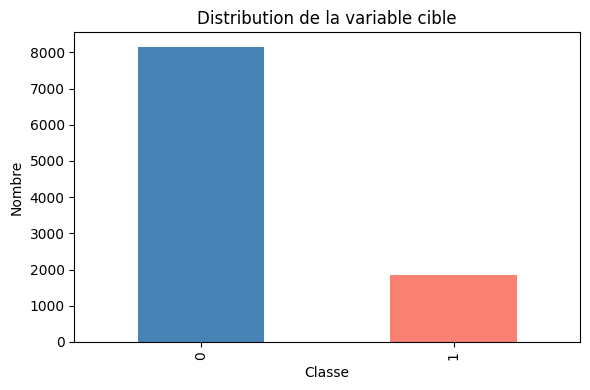

In [10]:
#1 Distribution de la variable cible
print(" Distribution de la colonne cible :")
print(df['default'].value_counts())

plt.figure(figsize=(6,4))
df['default'].value_counts().plot(kind='bar', color=['steelblue','salmon'])
plt.title("Distribution de la variable cible")
plt.xlabel("Classe")
plt.ylabel("Nombre")
plt.tight_layout()
plt.show()


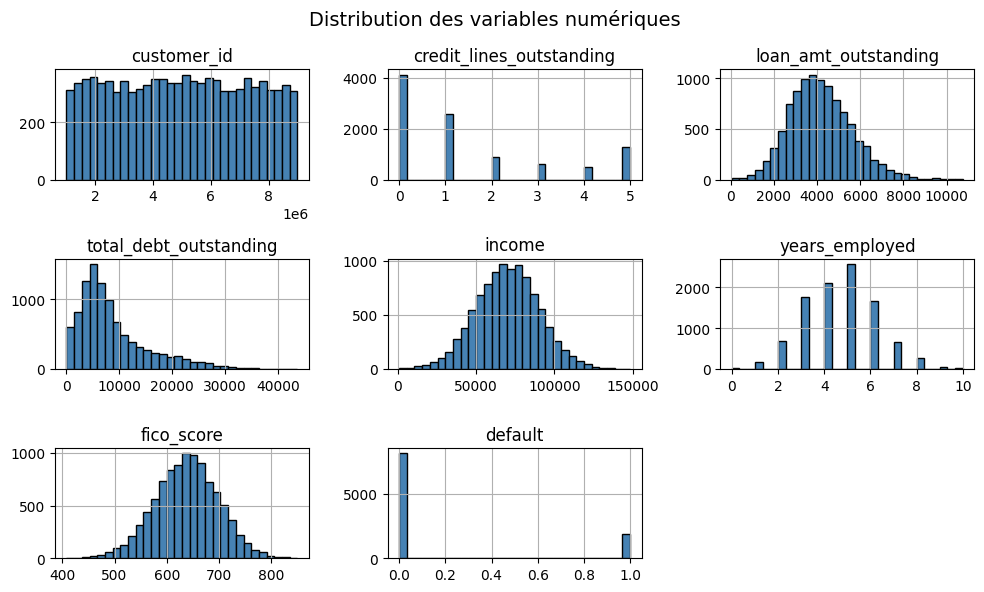

In [11]:
# 2. Distribution des variables numériques 
df.hist(figsize=(10,6), bins=30, color='steelblue', edgecolor='black')
plt.suptitle("Distribution des variables numériques", fontsize=14)
plt.tight_layout()
plt.show()

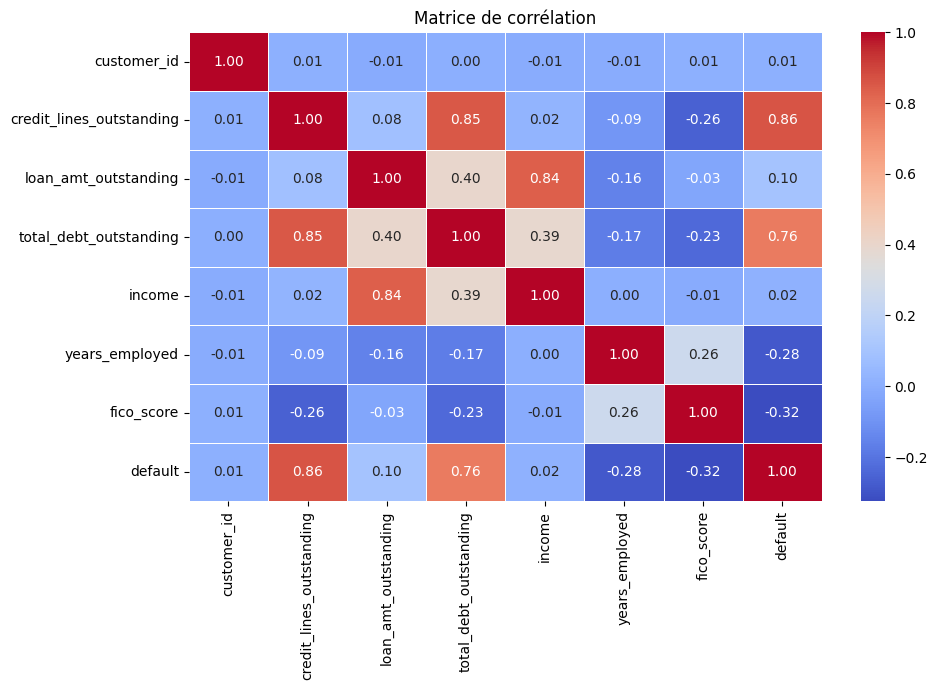

In [12]:
#3. Matrice de corrélation
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f",
            cmap='coolwarm', linewidths=0.5)
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()

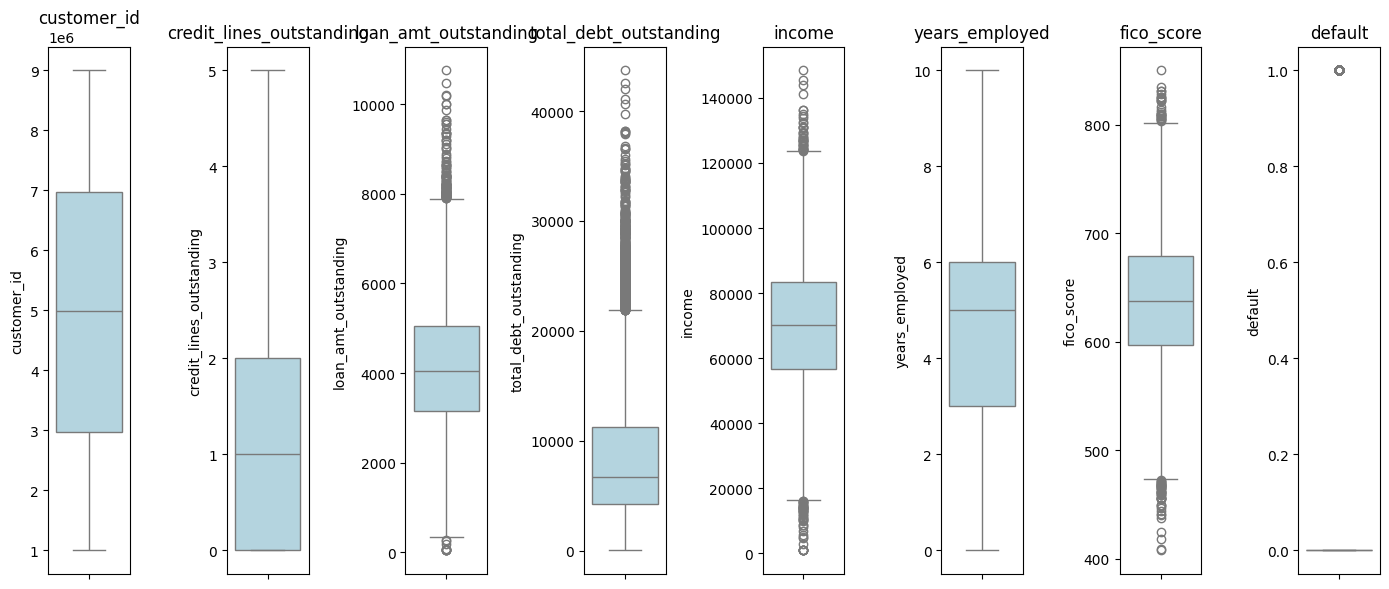

In [13]:
# 4. Boxplots pour détecter les outliers 
num_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(14,6))
for i, col in enumerate(num_cols):
    plt.subplot(1, len(num_cols), i+1)
    sns.boxplot(y=df[col], color='lightblue')
    plt.title(col)
plt.tight_layout()
plt.show()

# 5 - Preprocessing

In [14]:
# Supprimer customer_id
df = df.drop(columns=['customer_id'])

In [15]:
# Séparer X et y
X = df.drop(columns=['default'])
y = df['default']

features = list(X.columns)
print(f"Features : {features}")

Features : ['credit_lines_outstanding', 'loan_amt_outstanding', 'total_debt_outstanding', 'income', 'years_employed', 'fico_score']


In [16]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (8000, 6), Test: (2000, 6)


In [17]:
# Normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Normalisation effectuée !")

Normalisation effectuée !


# 6 - Entraînement des modèles

In [18]:
# 1- Logistic Regression 
lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression :")
print(classification_report(y_test, y_pred_lr))
print(f"AUC-ROC : {roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1]):.4f}\n")

Logistic Regression :
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      1630
           1       0.98      1.00      0.99       370

    accuracy                           1.00      2000
   macro avg       0.99      1.00      0.99      2000
weighted avg       1.00      1.00      1.00      2000

AUC-ROC : 1.0000



In [19]:
# 2- Random Forest 
rf = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest :")
print(classification_report(y_test, y_pred_rf))
print(f"AUC-ROC : {roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]):.4f}\n")

Random Forest :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1630
           1       0.99      0.98      0.99       370

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000

AUC-ROC : 0.9999



In [20]:
# 3- Gradient Boosting 
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

print("Gradient Boosting :")
print(classification_report(y_test, y_pred_gb))
print(f"AUC-ROC : {roc_auc_score(y_test, gb.predict_proba(X_test)[:,1]):.4f}\n")

Gradient Boosting :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1630
           1       0.99      0.99      0.99       370

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

AUC-ROC : 0.9999



# 7- Selection du meilleur modèle et sauvegarde

In [21]:
# 1- Sélection automatique du meilleur modèle 
models_compare = {
    "Logistic Regression" : (lr, X_test_scaled),
    "Random Forest"       : (rf, X_test),
    "Gradient Boosting"   : (gb, X_test),
}

best_name  = None
best_auc   = 0
best_model = None

for name, (model, X_data) in models_compare.items():
    auc = roc_auc_score(y_test, model.predict_proba(X_data)[:, 1])
    print(f"{name} — AUC : {auc:.4f}")
    if auc > best_auc:
        best_auc   = auc
        best_model = model
        best_name  = name

print(f"\n Le meilleur modèle : {best_name} (AUC = {best_auc:.4f})")

# 2- Sauvegarde 
os.makedirs('models', exist_ok=True)
joblib.dump(best_model, 'models/best_model.pkl')
joblib.dump(scaler,     'models/scaler.pkl')
joblib.dump(features,   'models/features.pkl')

print("Le meilleur modèle sauvegardé !")

Logistic Regression — AUC : 1.0000
Random Forest — AUC : 0.9999
Gradient Boosting — AUC : 0.9999

 Le meilleur modèle : Logistic Regression (AUC = 1.0000)
Le meilleur modèle sauvegardé !


# 8 — Courbes ROC

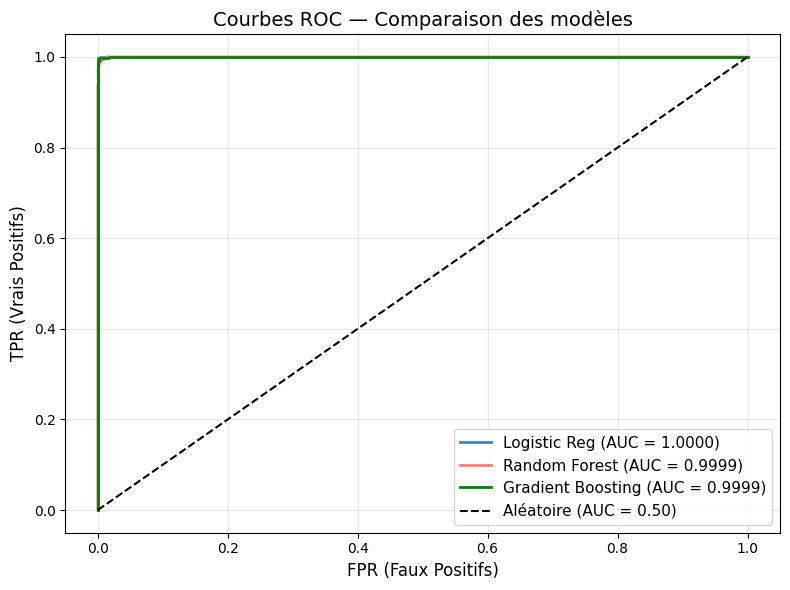

In [22]:
# Courbes de ROC comparatives des modèles
models_dict = {
    'Logistic Reg'     : (lr, X_test_scaled),  
    'Random Forest'    : (rf, X_test),          
    'Gradient Boosting': (gb, X_test),          
}
colors = ['steelblue', 'salmon', 'green']

plt.figure(figsize=(8, 6))

for (name, (model, X_data)), color in zip(models_dict.items(), colors):
    y_proba = model.predict_proba(X_data)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC = {auc:.4f})")

plt.plot([0,1], [0,1], 'k--', lw=1.5, label='Aléatoire (AUC = 0.50)')
plt.xlabel("FPR (Faux Positifs)", fontsize=12)
plt.ylabel("TPR (Vrais Positifs)", fontsize=12)
plt.title("Courbes ROC — Comparaison des modèles", fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 9 — Sauvegarde MLflow + joblib

In [23]:
# MLflow 
mlflow.set_tracking_uri("sqlite:///mlflow.db") 
mlflow.set_experiment("Loan_Default_Prediction")

with mlflow.start_run(run_name="LogisticRegression_Best"):
    mlflow.log_param("model",        "LogisticRegression")
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("max_iter",     1000)
    mlflow.log_metric("accuracy",    1.0)
    mlflow.log_metric("auc_roc",     1.0)
    mlflow.sklearn.log_model(lr, name="logistic_regression_model")
    print(f"MLflow — Run ID : {mlflow.active_run().info.run_id}")

# Joblib 
os.makedirs('models', exist_ok=True)
joblib.dump(lr,      'models/best_model.pkl')
joblib.dump(scaler,  'models/scaler.pkl')
joblib.dump(features,'models/features.pkl')

print(" Les modèles sauvegardés dans /models/")


2026/03/30 21:22:48 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/30 21:22:48 INFO mlflow.store.db.utils: Updating database tables
2026/03/30 21:22:49 INFO mlflow.tracking.fluent: Experiment with name 'Loan_Default_Prediction' does not exist. Creating a new experiment.
2026/03/30 21:22:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MLflow — Run ID : f2ac3e3af4994735ad568fa6006b5194
 Les modèles sauvegardés dans /models/
